In [1]:
### See the LBC file used

In [2]:
import os
import glob
import fnmatch

import pandas as pd
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point, Polygon

import xarray as xr
import numpy as np

import matplotlib.pyplot as plt # Core library for plotting
import matplotlib.cm as cm # To use different colormaps
import cartopy.crs as ccrs # For map projection
import seaborn as sns # boxplot


/home/taoma528/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
import sys
sys.path.insert(0,'/home/taoma528/Scripts/CESM_analysis/functions/')

from Plot_2D import Plot_2D # To draw a map

SCRIP_CONUS = '/home/taoma528/Scripts/CESM_analysis/functions/ne0CONUS_ne30x8_np4_SCRIP.nc'
SCRIP_ne30 = '/home/taoma528/Scripts/CESM_analysis/functions/ne30np4_091226_pentagons.nc'

In [4]:
LBC_filepath = '/net/fs09/d0/taoma528/cheyenne_copies/acom/MUSICA/emissions/LBC_17500116-25001216_CMIP6_SSP585_0p5degLat_c20200824.nc'

In [5]:
# Open Xarray dataset
LBC_ds = xr.open_dataset(LBC_filepath)

/tmp/ipykernel_512/230209806.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  LBC_ds = xr.open_dataset(LBC_filepath)
/tmp/ipykernel_512/230209806.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  LBC_ds = xr.open_dataset(LBC_filepath)
/tmp/ipykernel_512/230209806.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  LBC_ds = xr.open_dataset(LBC_filepath

In [8]:
CH4_LBC_da = LBC_ds.CH4_LBC
CH4_LBC_da

<xarray.DataArray 'CH4_LBC' (time: 9012, lat: 360)> Size: 13MB
[3244320 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * time     (time) object 72kB 1750-01-16 12:00:00 ... 2500-07-11 12:00:00
Attributes:
    long_name:  CH4 (methane) lower boundary condition
    units:      mol/mol

In [15]:
CH4_LBC_da.isel(time=3200)

<xarray.DataArray 'CH4_LBC' (lat: 360)> Size: 1kB
[360 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
    time     object 8B 2016-08-06 00:00:00
Attributes:
    long_name:  CH4 (methane) lower boundary condition
    units:      mol/mol

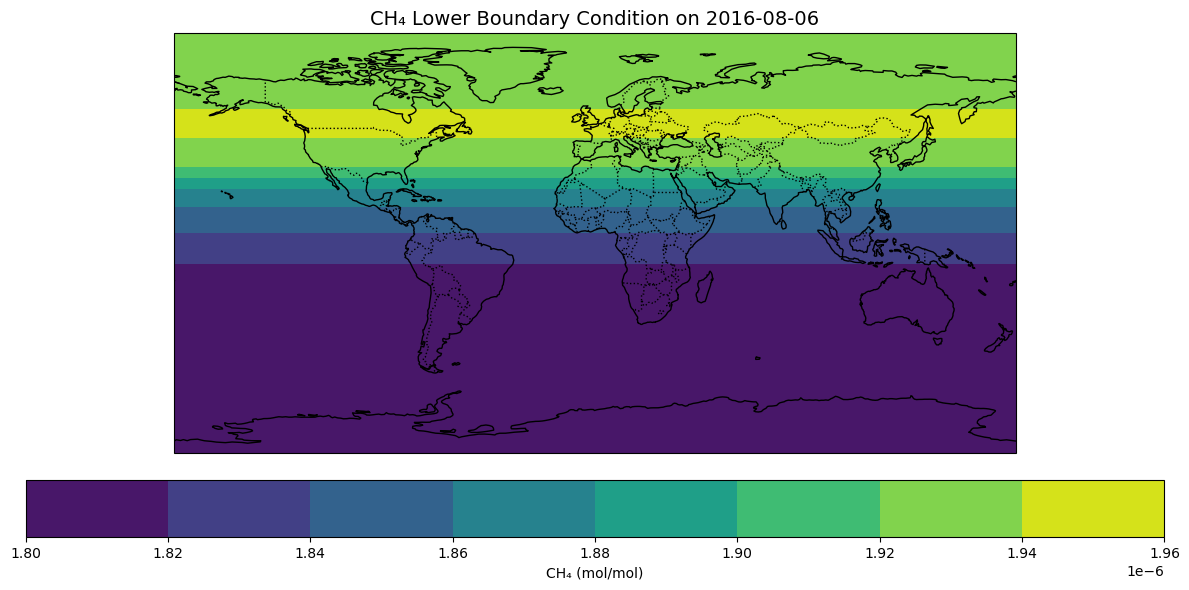

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr

# Example: extract a 1D DataArray over lat
da = CH4_LBC_da.isel(time=3200)
lats = da['lat'].values
data_1d = da.values

# Create fake longitudes to make it 2D
lons = np.linspace(-180, 180, 720)  # 0.5 degree resolution
data_2d = np.tile(data_1d[:, np.newaxis], (1, len(lons)))

# Create meshgrid
lon2d, lat2d = np.meshgrid(lons, lats)

# Plot
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
cf = ax.contourf(lon2d, lat2d, data_2d, transform=ccrs.PlateCarree(), cmap='viridis')

# Add features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_global()
ax.set_title('CH₄ Lower Boundary Condition on 2016-08-06', fontsize=14)

# Add colorbar
cbar = plt.colorbar(cf, orientation='horizontal', pad=0.05)
cbar.set_label('CH₄ (mol/mol)')

plt.tight_layout()
plt.show()
